In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from sklearn.metrics import roc_auc_score, f1_score

BATCH_SIZE = 512
EPOCHS = 100
LR = 8e-3
DEVICE = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print('using', DEVICE)

using mps


In [2]:
training_data = datasets.CIFAR10(
    root="../data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.CIFAR10(
    root="../data",
    train=False,
    download=True,
    transform=ToTensor()
)

train_dataloader = DataLoader(training_data, batch_size=BATCH_SIZE)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE)

In [3]:
next(iter(train_dataloader))[1]

tensor([6, 9, 9, 4, 1, 1, 2, 7, 8, 3, 4, 7, 7, 2, 9, 9, 9, 3, 2, 6, 4, 3, 6, 6,
        2, 6, 3, 5, 4, 0, 0, 9, 1, 3, 4, 0, 3, 7, 3, 3, 5, 2, 2, 7, 1, 1, 1, 2,
        2, 0, 9, 5, 7, 9, 2, 2, 5, 2, 4, 3, 1, 1, 8, 2, 1, 1, 4, 9, 7, 8, 5, 9,
        6, 7, 3, 1, 9, 0, 3, 1, 3, 5, 4, 5, 7, 7, 4, 7, 9, 4, 2, 3, 8, 0, 1, 6,
        1, 1, 4, 1, 8, 3, 9, 6, 6, 1, 8, 5, 2, 9, 9, 8, 1, 7, 7, 0, 0, 6, 9, 1,
        2, 2, 9, 2, 6, 6, 1, 9, 5, 0, 4, 7, 6, 7, 1, 8, 1, 1, 2, 8, 1, 3, 3, 6,
        2, 4, 9, 9, 5, 4, 3, 6, 7, 4, 6, 8, 5, 5, 4, 3, 1, 8, 4, 7, 6, 0, 9, 5,
        1, 3, 8, 2, 7, 5, 3, 4, 1, 5, 7, 0, 4, 7, 5, 5, 1, 0, 9, 6, 9, 0, 8, 7,
        8, 8, 2, 5, 2, 3, 5, 0, 6, 1, 9, 3, 6, 9, 1, 3, 9, 6, 6, 7, 1, 0, 9, 5,
        8, 5, 2, 9, 0, 8, 8, 0, 6, 9, 1, 1, 6, 3, 7, 6, 6, 0, 6, 6, 1, 7, 1, 5,
        8, 3, 6, 6, 8, 6, 8, 4, 6, 6, 1, 3, 8, 3, 4, 1, 7, 1, 3, 8, 5, 1, 1, 4,
        0, 9, 3, 7, 4, 9, 9, 2, 4, 9, 9, 1, 0, 5, 9, 0, 8, 2, 1, 2, 0, 5, 6, 3,
        2, 7, 8, 8, 6, 0, 7, 9, 4, 5, 6,

In [4]:
class CustomCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding = 'same'),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),
            nn.Flatten(),
            nn.Linear(32*32*32//4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )
    def forward(self, input):
        logits = self.model(input)
        return logits

In [5]:
model = CustomCNN().to(DEVICE)
loss_fn = nn.CrossEntropyLoss().to(DEVICE)
optimizer = torch.optim.RMSprop(model.parameters(), lr=LR)

In [6]:
train_loss_history = []
test_loss_history = []
test_auc_history = []
test_f1_history = []

print("Epoch train_loss test_loss test_auc test_f1")
for epoch in range(1, EPOCHS+1):
    train_loss = 0
    model.train()
    for batch, (X, y) in enumerate(train_dataloader):
        X, y = X.to(DEVICE), y.to(DEVICE)
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        train_loss += loss.item()

    test_loss = 0
    labels = []
    softmax_preds = []
    preds = []
    model.eval()
    for batch, (X, y) in enumerate(test_dataloader):
        X, y = X.to(DEVICE), y.to(DEVICE)
        pred = model(X)
        loss = loss_fn(pred, y)
        test_loss += loss.item()
        labels.extend(y.cpu().numpy())
        softmax_preds.extend(nn.Softmax(-1)(pred).cpu().detach().tolist())
        preds.extend(pred.argmax(-1).cpu().detach().tolist())
    auc = roc_auc_score(labels, softmax_preds, multi_class='ovr')
    f1 = f1_score(labels, preds, average='macro')
    print(epoch, train_loss / len(training_data), test_loss / len(test_data), auc, f1)
    train_loss_history.append(train_loss / len(training_data))
    test_loss_history.append(test_loss / len(test_data))
    test_auc_history.append(auc)
    test_f1_history.append(f1)

Epoch train_loss test_loss test_auc test_f1
1 0.029224429185390473 0.003935867393016815 0.7665103777777779 0.2805737589121885
2 0.0038117466735839846 0.0035975038290023804 0.8112327722222222 0.3495765702273358
3 0.0035876009917259217 0.0036005733847618102 0.8233265611111114 0.3691055023512063
4 0.003515209448337555 0.003198443365097046 0.8520230944444445 0.4123437982146526
5 0.0034821279287338257 0.003350135672092438 0.8455240555555555 0.3993088560770034
6 0.0033632931184768675 0.003480804407596588 0.8258405277777777 0.3629227831069594
7 0.0034630656170845033 0.0036036054134368895 0.8045871611111112 0.3590278724382996
8 0.0033771499514579774 0.0030715516686439515 0.8629220166666667 0.4464177139232435
9 0.0032212949562072752 0.002963710367679596 0.8735591833333334 0.46876791375106625
10 0.004496274273395539 0.0032770025849342345 0.8379733444444444 0.3874017964072531
11 0.003278742582798004 0.003254499328136444 0.843486327777778 0.4204021743215135
12 0.0031716196298599243 0.0029480661392

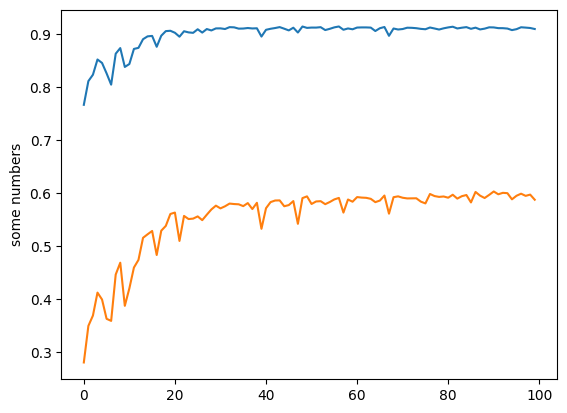

In [7]:
import matplotlib.pyplot as plt

plt.plot(test_auc_history)
plt.plot(test_f1_history)
plt.ylabel('some numbers')
plt.show()

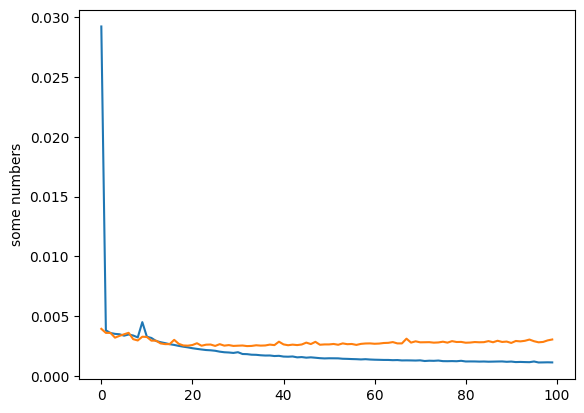

In [8]:
plt.plot(train_loss_history)
plt.plot(test_loss_history)
plt.ylabel('some numbers')
plt.show()

In [9]:
pred.shape

torch.Size([272, 10])

In [10]:
X.shape

torch.Size([272, 3, 32, 32])